In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import plot_model, plot_wage_gap, plot_mean_age_high_skill

import copy


# params_to_latex(par)

# np.set_printoptions(threshold=np.inf)

## Increase chance of being reassigned

In [2]:
# Baseline
model = ModelClass()
model.solve(do_print=False)


In [4]:
first_period = 10
second_period = 20

rho_baseline = model.par.rho.copy()

# Periods 0-9: baseline
model.par.rho = rho_baseline.copy()
model.par.T_max = first_period
model.generate_transition(t_end=first_period - 1, do_print=False)
sol1 = copy.deepcopy(model.sol)

# Generate an initial steady-state column plus 20 shocked periods.
model.par.rho = rho_baseline ** 0.5
model.par.T_max = second_period + 1
model.generate_transition(t_end=second_period, do_print=False)
sol2 = copy.deepcopy(model.sol)

# Drop sol2 period 0 because it is the duplicated pre-shock steady state.
for name, x1 in vars(sol1).items():
    x2 = getattr(sol2, name)

    if isinstance(x1, np.ndarray) and isinstance(x2, np.ndarray):
        if x1.ndim == 1 and x1.shape[0] == first_period and x2.shape[0] == second_period + 1:
            setattr(model.sol, name, np.concatenate((x1, x2[1:]), axis=0))

        elif x1.ndim == 2 and x1.shape[-1] == first_period and x2.shape[-1] == second_period + 1:
            setattr(model.sol, name, np.concatenate((x1, x2[:, 1:]), axis=-1))

model.par.T_max = first_period + second_period

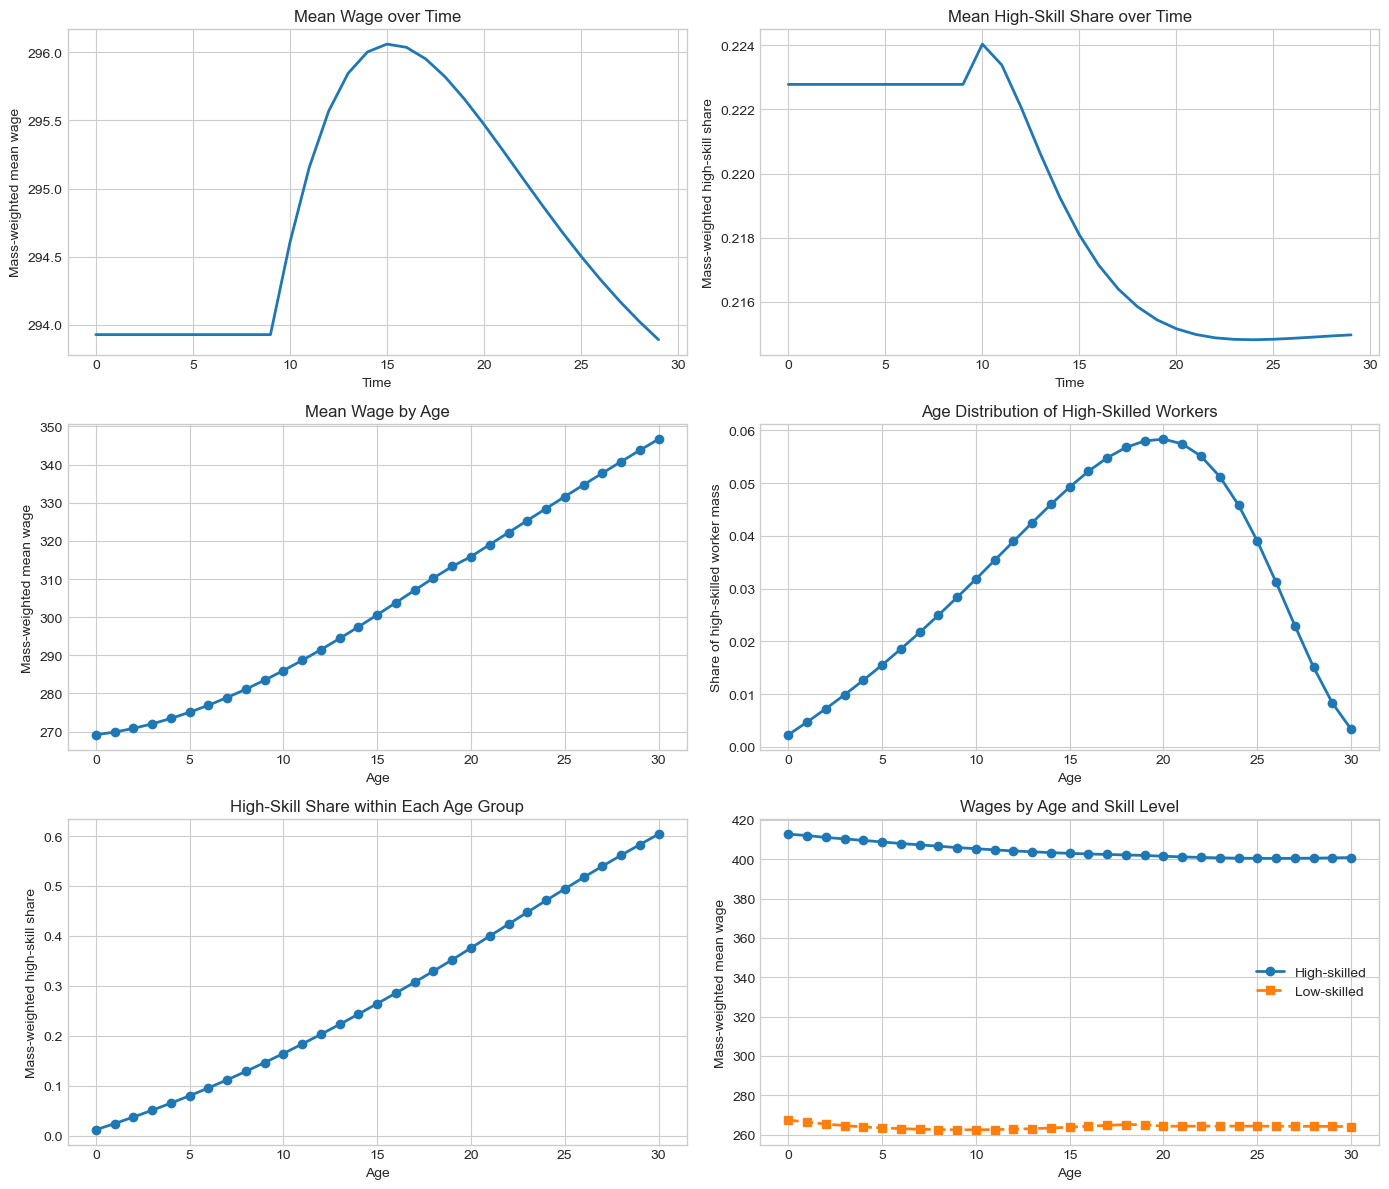

In [ ]:
plot_model(model)

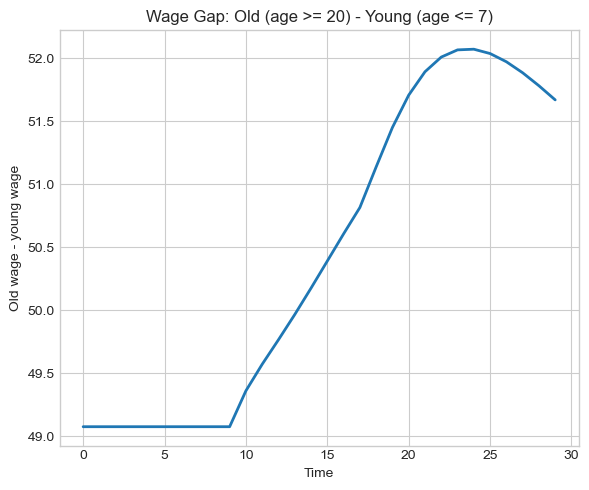

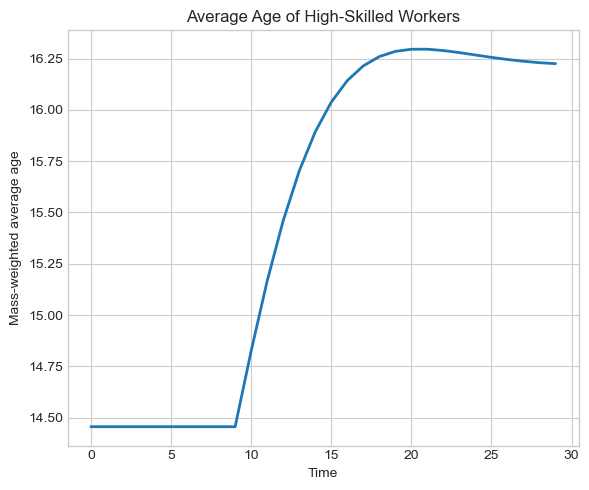

In [5]:
plot_wage_gap(model, young_max=7, old_min=20, x_size=6, y_size=5)
plot_mean_age_high_skill(model, x_size=6, y_size=5)

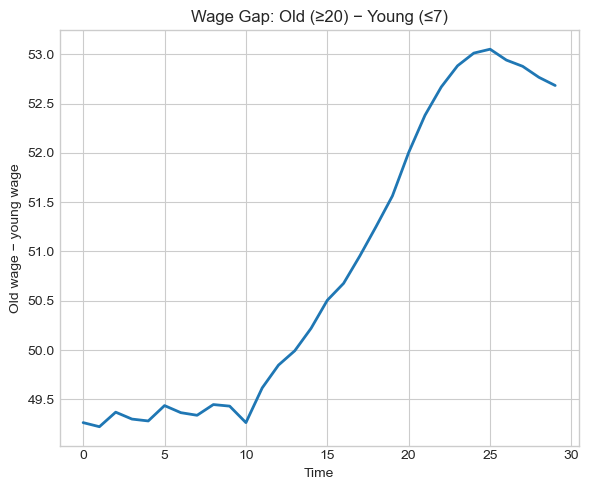

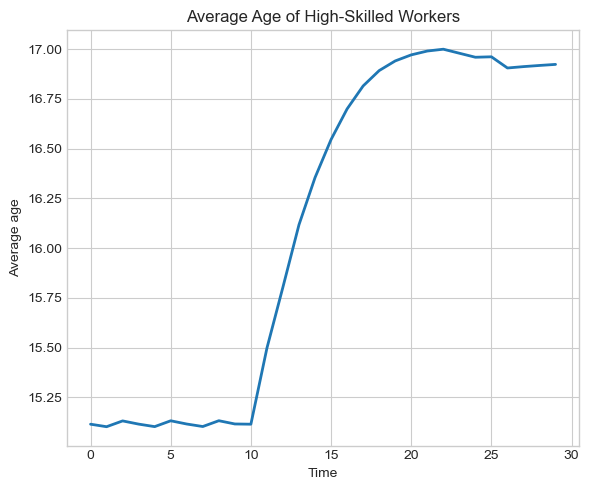